# Regresión lineal múltiple: reserva automática y ocupación por ciudad

**Sprint 2 — EDA / Análisis por pregunta de negocio (Operaciones y gestión de inventario)**

**Pregunta de negocio:** ¿Qué repercusión tiene la opción de reserva
automática (`is_instant_bookable`) en la ocupación media de cada ciudad?

Este notebook desarrolla la propuesta descrita en la *Justificación
técnica*: una regresión lineal múltiple que aísla el efecto de la
reserva automática sobre la ocupación, controlando por ciudad, precio,
capacidad, tipo de alojamiento y valoración.

Siguiendo la observación de la mentora Verónica:
- Se habla de **ocupación** (días ocupados) y no de disponibilidad.
- La variable dependiente se expresa en **ocupación en días**, no en
  porcentaje, ya que se va a modelar con regresión lineal.
- Se revisa con cuidado la posible **multicolinealidad** entre
  `bedrooms` (número de habitaciones), `room_type` (tipo de alojamiento)
  y `accommodates` (capacidad), antes de dar por buenos los
  coeficientes del modelo.

El análisis avanza **de lo general a lo particular**: primero una
foto agregada de la ocupación por ciudad y por reserva automática,
después la revisión de colinealidad entre variables explicativas, y
por último el modelo de regresión múltiple con su verificación de
supuestos.

## 1. Librerías

In [35]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import jarque_bera
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Carga de datos

Partimos del dataset ya transformado por el equipo
(`clean_dataset_29_06_2026.csv`), que ya incluye las columnas de
ocupación (`occupancy_30/60/90/365`) y la variable
`is_instant_bookable_numeric` generadas en la fase de Data
Transformation.

**Aviso:** este archivo tiene menos registros que el dataset general
de EDA (transformación de la semana pasada). Se usa aquí porque ya
contiene las columnas necesarias; si Data Cleaning ha entregado una
versión más reciente, actualizar la ruta antes de dar el análisis
por definitivo (ver sección de limitaciones al final).

In [37]:
def encontrar_raiz_proyecto(nombre_carpeta='Equip_34'):
    '''
    Sube desde el directorio actual hasta encontrar la carpeta
    raíz del proyecto.
    '''
    actual = Path.cwd()
    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta
    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}' subiendo desde {actual}"
    )

raiz_proyecto = encontrar_raiz_proyecto('Equip_34')
ruta = raiz_proyecto / 'Data' / 'raw_dataset_29_06_2026.csv'

print(f"Ruta resuelta: {ruta}")
df = pd.read_csv(ruta)
print(df.shape)
df.head()

Ruta resuelta: c:\Users\giorg\Desktop\ProjecteData\Equip_34\Data\raw_dataset_29_06_2026.csv
(7001, 35)


,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1.0,...,100.0,100.0,100.0,100.0,100.0,FALSO,75.0,spain,malaga,31/07/2018
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,90.0,100.0,100.0,80.0,90.0,FALSO,52.0,spain,madrid,10/01/2020
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,100.0,100.0,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,29/07/2019
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,...,90.0,100.0,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,10/01/2020
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2.0,...,100.0,100.0,100.0,100.0,100.0,FALSO,39.0,spain,girona,19/02/2019


In [38]:
plazos = {'30': 30, '60': 60, '90': 90, '365': 365}

for suf, total in plazos.items():
    df[f'occupancy_{suf}'] = total - df[f'availability_{suf}']
    df[f'occupancy_rate_{suf}'] = (df[f'occupancy_{suf}'] / total * 100).round(2)

#muestra de las nuevas columnas de ocupación
df[[f'occupancy_{suf}' for suf in plazos.keys()] + [f'occupancy_rate_{suf}' for suf in plazos.keys()]].head()

,occupancy_30,occupancy_60,occupancy_90,occupancy_365,occupancy_rate_30,occupancy_rate_60,occupancy_rate_90,occupancy_rate_365
0,23,40,50,235,76.67,66.67,55.56,64.38
1,30,60,90,203,100.00,100.00,100.00,55.62
2,4,29,59,95,13.33,48.33,65.56,26.03
3,21,37,41,65,70.00,61.67,45.56,17.81
4,30,41,41,53,100.00,68.33,45.56,14.52


In [39]:
df['is_instant_bookable_numeric'] = df['is_instant_bookable'].map({'VERDADERO': 1, 'FALSO': 0})

print(df['is_instant_bookable_numeric'].value_counts(dropna=False))
print(df['is_instant_bookable'].value_counts(dropna=False))

df[['is_instant_bookable', 'is_instant_bookable_numeric']].head()

is_instant_bookable_numeric
1    3740
0    3261
Name: count, dtype: int64
is_instant_bookable
VERDADERO    3740
FALSO        3261
Name: count, dtype: int64


,is_instant_bookable,is_instant_bookable_numeric
0,FALSO,0
1,FALSO,0
2,VERDADERO,1
3,VERDADERO,1
4,FALSO,0


## 3. Selección de variables para el análisis

Variable dependiente y explicativas según la justificación técnica:

| Rol | Variable | Descripción |
|---|---|---|
| Dependiente | `occupancy_365` | Días ocupados en un año (0-365) |
| Interés | `is_instant_bookable_numeric` | Reserva automática (1 = sí, 0 = no) |
| Control | `city` | Ciudad (8 categorías) |
| Control | `price_€` | Precio por noche |
| Control | `accommodates` | Capacidad |
| Control | `bedrooms` | Número de habitaciones |
| Control | `room_type` | Tipo de alojamiento (4 categorías) |
| Control | `review_scores_rating` | Valoración |

Se trabaja sobre una copia reducida a estas columnas, y se eliminan
los registros con nulos en cualquiera de ellas (el modelo de
regresión no admite nulos).

In [40]:
df['is_instant_bookable_numeric'] = df['is_instant_bookable'].map({'VERDADERO': 1, 'FALSO': 0})

print(df['is_instant_bookable_numeric'].value_counts(dropna=False))
print(df['is_instant_bookable'].value_counts(dropna=False))

df[['is_instant_bookable', 'is_instant_bookable_numeric']].head()

is_instant_bookable_numeric
1    3740
0    3261
Name: count, dtype: int64
is_instant_bookable
VERDADERO    3740
FALSO        3261
Name: count, dtype: int64


,is_instant_bookable,is_instant_bookable_numeric
0,FALSO,0
1,FALSO,0
2,VERDADERO,1
3,VERDADERO,1
4,FALSO,0


In [41]:
for col in df.columns:
    print(col)

apartment_id
name
description
host_id
neighbourhood_name
neighbourhood_district
room_type
accommodates
bathrooms
bedrooms
beds
amenities_list
price
minimum_nights
maximum_nights
has_availability
availability_30
availability_60
availability_90
availability_365
number_of_reviews
first_review_date
last_review_date
review_scores_rating
review_scores_accuracy
review_scores_cleanliness
review_scores_checkin
review_scores_communication
review_scores_location
review_scores_value
is_instant_bookable
reviews_per_month
country
city
insert_date
occupancy_30
occupancy_rate_30
occupancy_60
occupancy_rate_60
occupancy_90
occupancy_rate_90
occupancy_365
occupancy_rate_365
is_instant_bookable_numeric


In [42]:
columnas_modelo = [
    'occupancy_365', 'occupancy_90', 'occupancy_60', 'occupancy_30',
    'is_instant_bookable_numeric', 'city', 'price', 'accommodates',
    'bedrooms', 'room_type', 'review_scores_rating'
]

df_modelo = df[columnas_modelo].copy()

print("Registros antes de eliminar nulos:", df_modelo.shape[0])
nulos = df_modelo.isna().sum()
print(nulos[nulos > 0])

df_modelo = df_modelo.dropna()
print("Registros tras eliminar nulos:", df_modelo.shape[0])

Registros antes de eliminar nulos: 7001
price                    131
bedrooms                  29
review_scores_rating    1327
dtype: int64
Registros tras eliminar nulos: 5568


## 5. Revisión de multicolinealidad

Verónica ha señalado que puede existir multicolinealidad entre:
`bedrooms` (número de habitaciones), `room_type` (tipo de alojamiento)
y `accommodates` (capacidad), ya que conceptualmente están muy
relacionadas (un alojamiento con más habitaciones suele tener más
capacidad y suele ser "Entire home/apt").

Se revisa esto **antes** de meter estas variables en el modelo.

## 6. Codificación de variables categóricas

`city` (8 categorías) y `room_type` (4 categorías) se convierten en
variables dummy, tal y como exige la justificación técnica.
Se usa `drop_first=True` para evitar la trampa de la variable
ficticia (dummy variable trap), que generaría colinealidad perfecta
entre las dummies de un mismo grupo.

## 4. Análisis general: de lo agregado a lo particular

Antes de entrar en el modelo, se observa el panorama general:
ocupación media por ciudad y por reserva automática.

In [43]:
ocupacion_por_ciudad = (
    df_modelo.groupby('city')['occupancy_365']
    .agg(['mean', 'median', 'std', 'count'])
    .round(1)
    .sort_values('mean', ascending=False)
)
ocupacion_por_ciudad

,mean,median,std,count
city,,,,
madrid,198.1,211.0,133.0,1224
valencia,184.8,188.0,124.9,284
barcelona,179.6,171.0,132.3,1744
menorca,167.0,185.5,120.9,114
sevilla,162.7,138.5,117.8,330
malaga,160.0,150.0,119.1,317
girona,156.4,129.5,129.0,764
mallorca,147.3,131.0,111.5,791


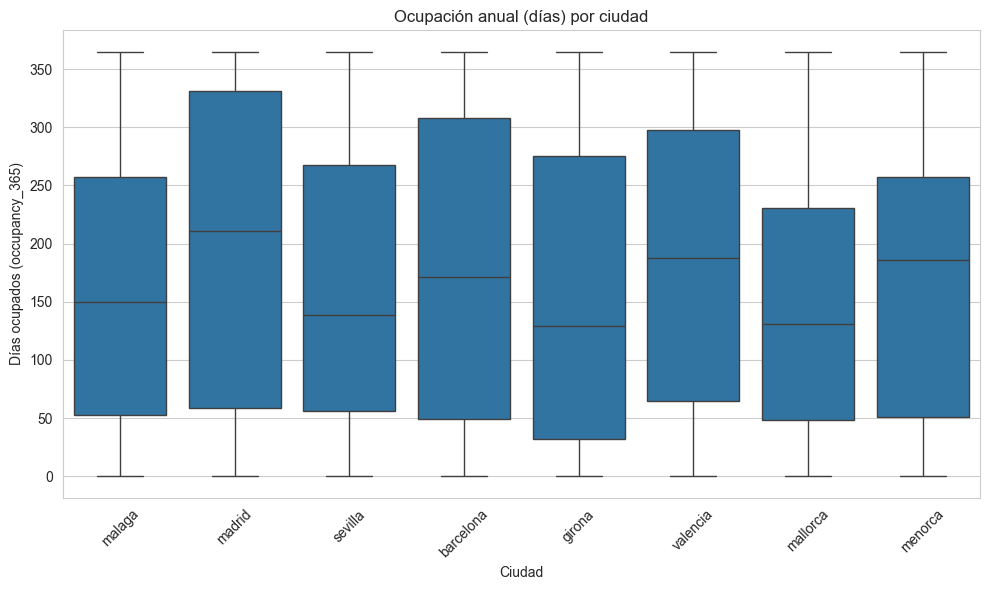

In [44]:
fig, ax = plt.subplots()
sns.boxplot(data=df_modelo, x='city', y='occupancy_365', ax=ax)
ax.set_title('Ocupación anual (días) por ciudad')
ax.set_xlabel('Ciudad')
ax.set_ylabel('Días ocupados (occupancy_365)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../Results/ocupacion_365_por_ciudad.png', dpi=150,
            bbox_inches='tight')
plt.show()

**Comparación bivariable de referencia** (reserva automática
sí/no, sin controlar por nada más). Se muestra solo como punto de
partida: como se explica en la justificación técnica, esta
comparación por sí sola **no permite aislar el efecto propio** de la
reserva automática, porque no controla por ciudad, capacidad, tipo de
alojamiento, etc.

In [45]:
comparacion_bivariable = (
    df_modelo.groupby('is_instant_bookable_numeric')['occupancy_365']
    .agg(['mean', 'median', 'std', 'count'])
    .round(1)
)
comparacion_bivariable

,mean,median,std,count
is_instant_bookable_numeric,,,,
0,172.7,160.0,133.1,2594
1,174.8,168.0,123.8,2974


C:\Users\giorg\AppData\Local\Temp\ipykernel_24204\4235940077.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No (0)', 'Sí (1)'])


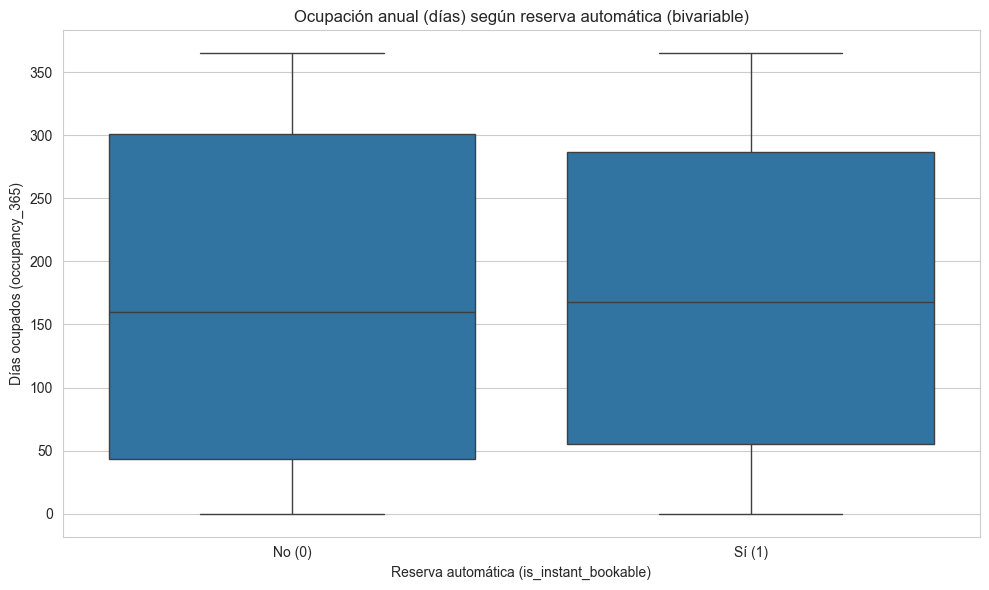

In [46]:
fig, ax = plt.subplots()
sns.boxplot(data=df_modelo, x='is_instant_bookable_numeric',
            y='occupancy_365', ax=ax)
ax.set_xticklabels(['No (0)', 'Sí (1)'])
ax.set_title('Ocupación anual (días) según reserva automática (bivariable)')
ax.set_xlabel('Reserva automática (is_instant_bookable)')
ax.set_ylabel('Días ocupados (occupancy_365)')
plt.tight_layout()
plt.show()

Matriz de correlación general entre las variables numéricas del conjunto de trabajo.

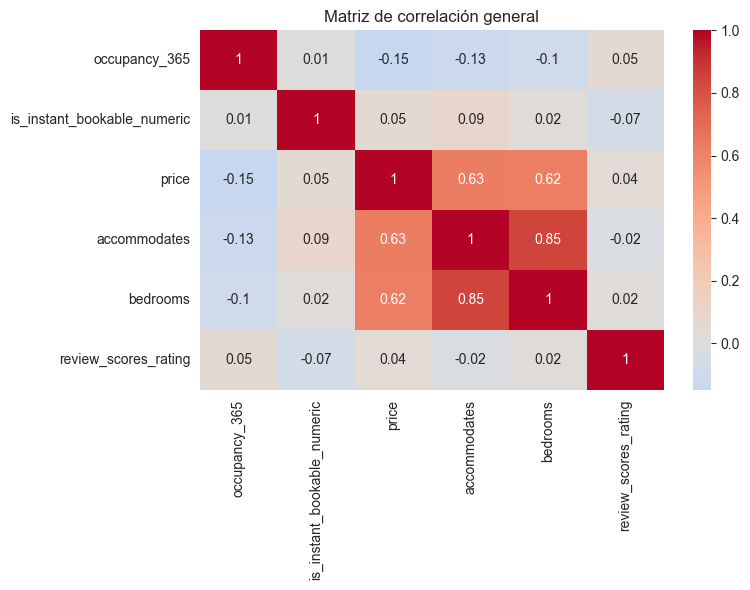

In [47]:
numericas = ['occupancy_365', 'is_instant_bookable_numeric',
             'price', 'accommodates', 'bedrooms',
             'review_scores_rating']

matriz_corr = df_modelo[numericas].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de correlación general')
plt.tight_layout()
plt.show()

Correlación bedrooms vs accommodates: 0.85


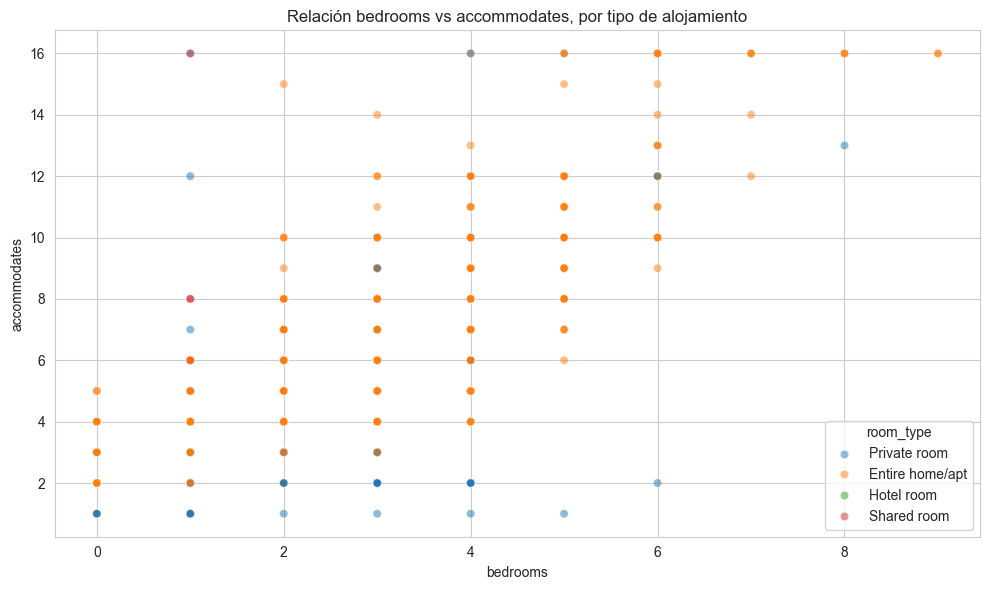

In [48]:
# Correlación numérica directa entre bedrooms y accommodates
corr_bed_acc = df_modelo[['bedrooms', 'accommodates']].corr().iloc[0, 1]
print(f"Correlación bedrooms vs accommodates: {corr_bed_acc:.2f}")

fig, ax = plt.subplots()
sns.scatterplot(data=df_modelo, x='bedrooms', y='accommodates',
                 hue='room_type', alpha=0.5, ax=ax)
ax.set_title('Relación bedrooms vs accommodates, por tipo de alojamiento')
plt.tight_layout()
plt.show()

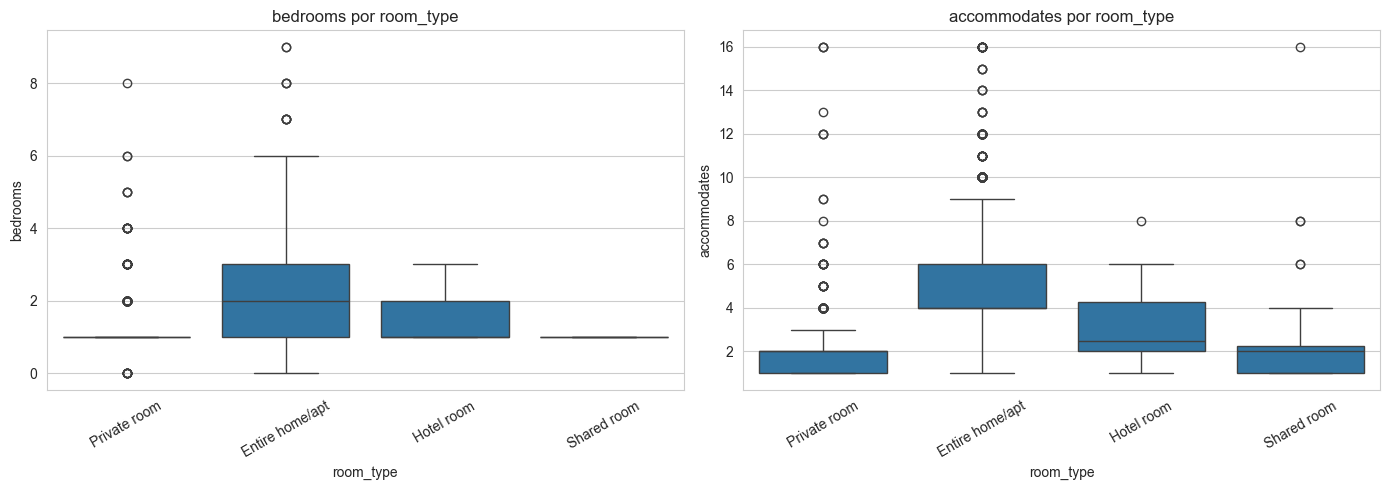

In [49]:
# Relación entre room_type y las otras dos variables (vía boxplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_modelo, x='room_type', y='bedrooms', ax=axes[0])
axes[0].set_title('bedrooms por room_type')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_modelo, x='room_type', y='accommodates', ax=axes[1])
axes[1].set_title('accommodates por room_type')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Lectura esperada:** si la correlación numérica y los boxplots
muestran una relación fuerte entre `bedrooms`, `accommodates` y
`room_type`, es probable que el VIF (calculado más abajo, ya con las
variables categóricas codificadas) confirme una multicolinealidad
relevante. En ese caso, el modelo final no debe incluir las tres
variables tal cual: se decide en la sección 7, con el VIF como
criterio objetivo, no a ojo.

In [50]:
df_dummies = pd.get_dummies(
    df_modelo,
    columns=['city', 'room_type'],
    drop_first=True,
    dtype=int
)

print("Categoría de referencia en 'city':",
      sorted(df_modelo['city'].unique())[0])
print("Categoría de referencia en 'room_type':",
      sorted(df_modelo['room_type'].unique())[0])

df_dummies.head()

Categoría de referencia en 'city': barcelona
Categoría de referencia en 'room_type': Entire home/apt


,occupancy_365,occupancy_90,occupancy_60,occupancy_30,is_instant_bookable_numeric,price,accommodates,bedrooms,review_scores_rating,city_girona,city_madrid,city_malaga,city_mallorca,city_menorca,city_sevilla,city_valencia,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,235,50,40,23,0,400.0,2,1.0,970.0,0,0,1,0,0,0,0,0,1,0
1,203,90,60,30,0,170.0,1,1.0,920.0,0,1,0,0,0,0,0,0,1,0
2,95,59,29,4,1,990.0,4,2.0,980.0,0,0,0,0,0,1,0,0,0,0
3,65,41,37,21,1,400.0,2,1.0,940.0,0,0,0,0,0,0,0,0,1,0
4,53,41,41,30,0,900.0,5,2.0,970.0,1,0,0,0,0,0,0,0,1,0


## 7. Regresión lineal múltiple — ocupación a 365 días

Variable dependiente: `occupancy_365` (días ocupados en el año).

Se calcula primero el modelo con todas las variables de control y su
VIF. Si alguna variable supera el umbral habitual de **VIF > 5**, se
elimina la de VIF más alto y se recalcula, de forma iterativa, hasta
que todas las variables explicativas queden por debajo del umbral.
Esto da respuesta objetiva a la duda de Verónica sobre
`bedrooms` / `room_type` / `accommodates`.

In [51]:
def calcular_vif(X):
    '''
    Calcula el VIF de cada variable explicativa. X debe incluir
    ya la constante (columna 'const').
    '''
    vif = pd.DataFrame()
    vif['variable'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i)
                  for i in range(X.shape[1])]
    return vif.sort_values('VIF', ascending=False)


variables_explicativas = [c for c in df_dummies.columns
                           if c not in ['occupancy_365', 'occupancy_90',
                                        'occupancy_60', 'occupancy_30']]

X = sm.add_constant(df_dummies[variables_explicativas])
vif_inicial = calcular_vif(X)
vif_inicial

,variable,VIF
0,const,130.991221
3,accommodates,4.755365
4,bedrooms,4.221611
2,price,1.849431
14,room_type_Private room,1.714515
9,city_mallorca,1.495961
6,city_girona,1.438351
7,city_madrid,1.419198
8,city_malaga,1.184409
11,city_sevilla,1.176927


In [52]:
# Eliminación iterativa de variables con VIF > 5 (excluyendo la
# constante y la variable de interés is_instant_bookable_numeric,
# que se mantiene siempre por ser el objeto de la pregunta de negocio)
X_iter = X.copy()
umbral_vif = 5

while True:
    vif_tabla = calcular_vif(X_iter)
    candidatas = vif_tabla[
        (vif_tabla['variable'] != 'const') &
        (vif_tabla['variable'] != 'is_instant_bookable_numeric') &
        (vif_tabla['VIF'] > umbral_vif)
    ]
    if candidatas.empty:
        break
    peor_variable = candidatas.iloc[0]['variable']
    print(f"Eliminando '{peor_variable}' (VIF = "
          f"{candidatas.iloc[0]['VIF']:.2f})")
    X_iter = X_iter.drop(columns=[peor_variable])

print("\nVariables explicativas finales tras control de VIF:")
vif_final = calcular_vif(X_iter)
vif_final


Variables explicativas finales tras control de VIF:


,variable,VIF
0,const,130.991221
3,accommodates,4.755365
4,bedrooms,4.221611
2,price,1.849431
14,room_type_Private room,1.714515
9,city_mallorca,1.495961
6,city_girona,1.438351
7,city_madrid,1.419198
8,city_malaga,1.184409
11,city_sevilla,1.176927


**Nota:** si `bedrooms` desaparece en este proceso, la
capacidad del alojamiento queda representada por `accommodates`
(variable continua, más granular) y por las dummies de `room_type`;
no se pierde información relevante para la pregunta de negocio,
que es sobre `is_instant_bookable_numeric`, variable que se
mantiene en el modelo pase lo que pase con las variables de control.

## 8. Modelo final y resultados

In [53]:
y = df_dummies['occupancy_365']
modelo_final = sm.OLS(y, X_iter).fit()
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:          occupancy_365   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     16.54
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           3.40e-43
Time:                        18:10:42   Log-Likelihood:                -34804.
No. Observations:                5568   AIC:                         6.964e+04
Df Residuals:                    5552   BIC:                         6.975e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

**Lectura del coeficiente de interés**

El coeficiente de `is_instant_bookable_numeric` indica cuántos días
más (o menos) de ocupación anual tiene, en promedio, un alojamiento
con reserva automática frente a uno sin ella, **manteniendo
constantes** el resto de variables del modelo (ciudad, precio,
capacidad, tipo de alojamiento y valoración).

Revisar en el `summary()`:
- El **signo** del coeficiente (positivo = más ocupación con reserva
  automática).
- El **p-valor** (`P>|t|`): si es menor a 0.05, el efecto se considera
  estadísticamente significativo.
- El **R² ajustado**: qué parte de la variabilidad de la ocupación
  explica el conjunto de variables del modelo.

## 9. Verificación de supuestos pendientes

Según la justificación técnica, quedaban dos supuestos por
verificar: **normalidad de los residuos** y **multicolinealidad**
(ya resuelta en la sección 7 con el VIF). Se añade también una
revisión visual de homocedasticidad.

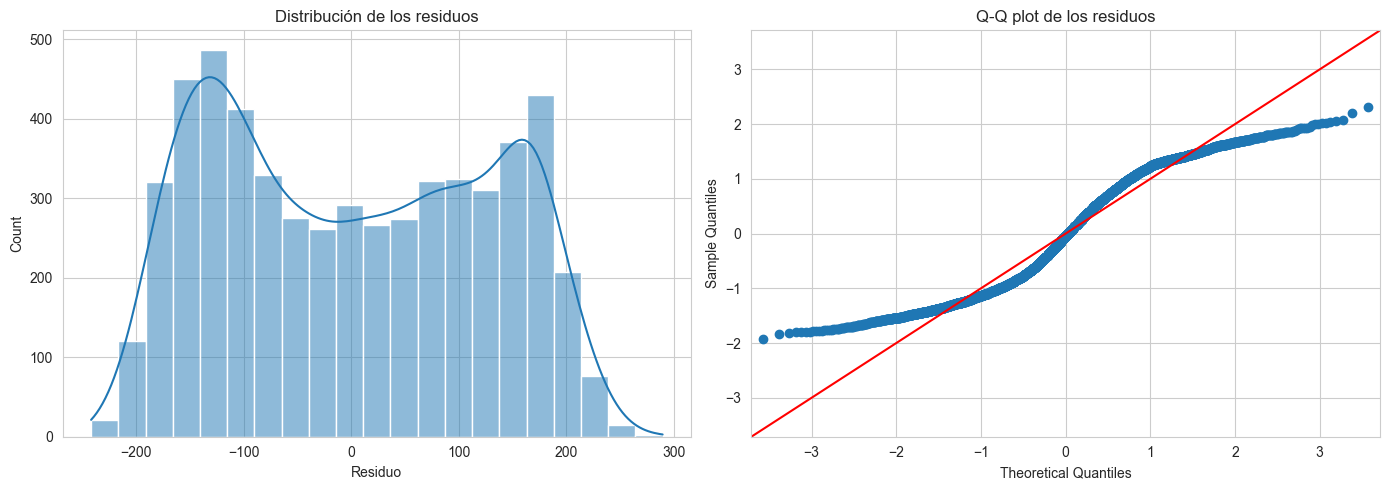

In [54]:
residuos = modelo_final.resid
valores_ajustados = modelo_final.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuos, kde=True, ax=axes[0])
axes[0].set_title('Distribución de los residuos')
axes[0].set_xlabel('Residuo')

sm.qqplot(residuos, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot de los residuos')

plt.tight_layout()
plt.savefig('../Results/residuos_modelo_ocupacion.png', dpi=150,
            bbox_inches='tight')
plt.show()

In [55]:
# Test de Jarque-Bera para normalidad de los residuos
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuos)
print(f"Jarque-Bera: estadístico={jb_stat:.2f}, p-valor={jb_pvalue:.4f}")
print("H0: los residuos siguen una distribución normal.")
print("Si p-valor < 0.05, se rechaza la normalidad de los residuos.")

Jarque-Bera: estadístico=404.46, p-valor=0.0000
H0: los residuos siguen una distribución normal.
Si p-valor < 0.05, se rechaza la normalidad de los residuos.


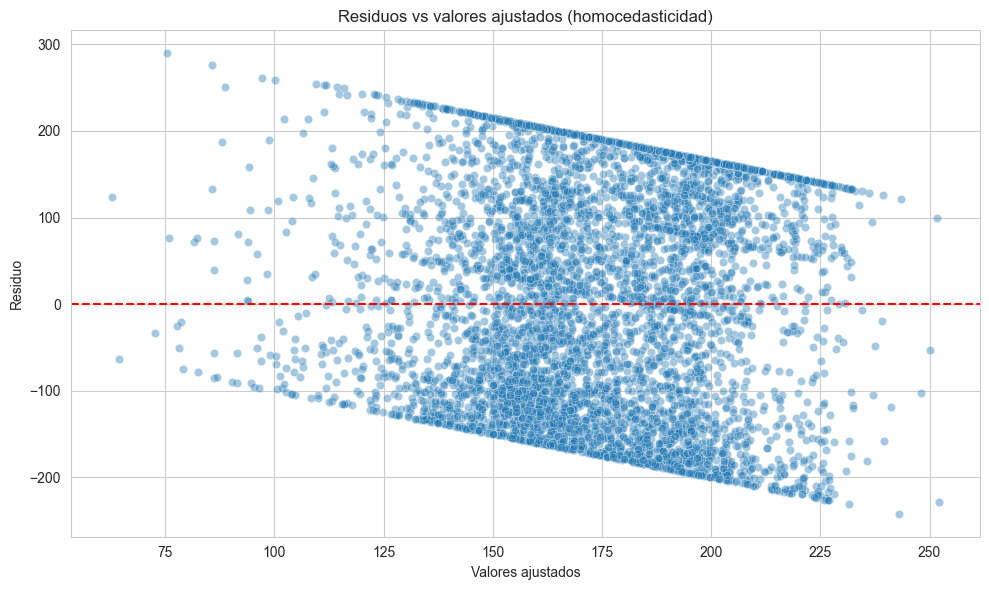

In [56]:
# Homocedasticidad: residuos vs valores ajustados
fig, ax = plt.subplots()
sns.scatterplot(x=valores_ajustados, y=residuos, alpha=0.4, ax=ax)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Residuos vs valores ajustados (homocedasticidad)')
ax.set_xlabel('Valores ajustados')
ax.set_ylabel('Residuo')
plt.tight_layout()
plt.show()

**Cómo interpretar esta sección:** una nube de puntos sin forma
de embudo alrededor del cero indica homocedasticidad razonable; un
histograma de residuos con forma de campana y puntos alineados en el
Q-Q plot apoyan la normalidad. Si estos supuestos no se cumplen bien,
los p-valores del modelo deben interpretarse con cautela (no invalidan
el modelo, pero piden prudencia en las conclusiones).

## 10. Robustez: repetir el modelo a 30, 60 y 90 días

La justificación técnica propone repetir el análisis para otros
horizontes de disponibilidad/ocupación, para ver si el efecto de la
reserva automática es estable o cambia según el plazo.

In [57]:
def ajustar_modelo_ocupacion(variable_dependiente, columnas_X):
    '''
    Ajusta un modelo OLS para la variable de ocupación indicada,
    usando el mismo conjunto de variables explicativas ya filtrado
    por VIF (columnas_X).
    '''
    X_modelo = sm.add_constant(df_dummies[columnas_X])
    y_modelo = df_dummies[variable_dependiente]
    return sm.OLS(y_modelo, X_modelo).fit()


columnas_finales = [c for c in X_iter.columns if c != 'const']

resultados_horizontes = {}
for horizonte in ['occupancy_30', 'occupancy_60', 'occupancy_90',
                   'occupancy_365']:
    modelo_h = ajustar_modelo_ocupacion(horizonte, columnas_finales)
    coef = modelo_h.params['is_instant_bookable_numeric']
    pval = modelo_h.pvalues['is_instant_bookable_numeric']
    resultados_horizontes[horizonte] = {
        'coeficiente_instant_bookable': round(coef, 2),
        'p_valor': round(pval, 4),
        'r2_ajustado': round(modelo_h.rsquared_adj, 3)
    }

pd.DataFrame(resultados_horizontes).T

,coeficiente_instant_bookable,p_valor,r2_ajustado
occupancy_30,0.56,0.0686,0.032
occupancy_60,0.53,0.3760,0.025
occupancy_90,0.54,0.5386,0.021
occupancy_365,8.66,0.0121,0.040


Esta tabla permite comparar, de un vistazo, si el efecto de la
reserva automática (coeficiente, significancia y R² ajustado) se
mantiene estable entre los distintos horizontes temporales o si
varía de forma relevante.

## 11. Conclusiones y propuestas

*(Completar tras ejecutar el notebook con los datos reales; guía de
qué debe contener cada punto)*

**Conclusiones a partir del modelo:**
- Indicar el signo, la magnitud y la significancia del coeficiente
  de `is_instant_bookable_numeric` en el modelo de 365 días.
- Indicar si el efecto es estable o varía entre 30/60/90/365 días
  (sección 10).
- Indicar si los supuestos de normalidad y homocedasticidad se
  cumplen razonablemente (sección 9), y matizar la confianza en los
  resultados si no es así.
- Recordar el alcance real del modelo: muestra **correlación
  controlada**, no causalidad, y depende de las variables incluidas.

**Propuestas de negocio (a ajustar según el signo del coeficiente):**
- Si el efecto es positivo y significativo: valorar incentivar o
  comunicar activamente la opción de reserva automática a los
  anfitriones de las ciudades con menor ocupación media (ver tabla
  de la sección 4), como palanca operativa de bajo coste.
- Si el efecto es pequeño o no significativo: no basar la estrategia
  de ocupación únicamente en la reserva automática; explorar otras
  variables de control (precio, valoración) que puedan tener un peso
  mayor según los coeficientes del modelo.
- En cualquier caso, comunicar el resultado como una asociación
  controlada por otros factores, no como una relación de causa-efecto,
  para evitar decisiones operativas basadas en una lectura
  simplificada del dato.

**Limitaciones y próximos pasos (heredados de la justificación
técnica):**
- El dataset usado aquí (`clean_dataset_29_06_2026.csv`, 6733 registros) es una versión previa a la actual del proyecto; conviene repetir el análisis con la versión de datos más reciente una vez confirmada por la mentora.
- No se incluyen variables como el tipo de anfitrión, que podrían
  explicar parte de la ocupación y no están en este modelo.
- Se recomienda validar los resultados con el resto del equipo antes
  de trasladarlos a Power BI o a la documentación final.